In [107]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import plot_model_comparison

import copy


# params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Increase chance of being reassigned

In [108]:
# Baseline
model = ModelClass()
model.solve(do_print=False)


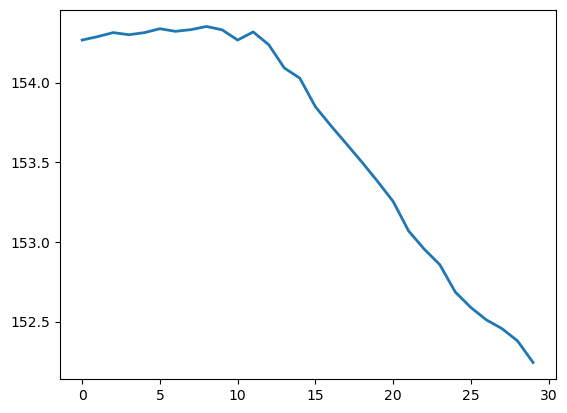

In [109]:
first_period = 10
model.par.T_max = first_period

model.generate_transition(t_end=model.par.T_max - 1, do_print=False)

sol1 = copy.deepcopy(model.sol)

second_period = 20
model.par.T_max = second_period

model.par.rho = model.par.rho ** 0.5
model.generate_transition(t_end=model.par.T_max - 1, do_print=False)
sol2 = copy.deepcopy(model.sol)

for name, x1 in vars(sol1).items():

    x2 = getattr(sol2, name)

    if isinstance(x1, np.ndarray):
        if x1.ndim == 1 and len(x1) == first_period:
            setattr(model.sol, name, np.concatenate((x1, x2), axis=0))

        elif x1.ndim == 2 and x1.shape[-1] == first_period:
            setattr(model.sol, name, np.concatenate((x1, x2), axis=-1))


plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)